In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.6f}".format)

# Load all processed data
ff5 = pd.read_csv(
    "../data/processed/ff5_factors.csv",
    index_col=0, parse_dates=True
)
returns = pd.read_csv(
    "../data/processed/stock_returns.csv",
    index_col=0, parse_dates=True
)
excess = pd.read_csv(
    "../data/processed/excess_returns.csv",
    index_col=0, parse_dates=True
)
factor_loadings = pd.read_csv(
    "../data/processed/ols_summary.csv",
    index_col=0
)
alpha_sig = pd.read_csv(
    "../data/processed/alpha_significance.csv",
    index_col=0
)

tickers  = ["AAPL", "BRK-B", "TSLA", "JNJ", "SPY"]
factors  = ["Mkt_RF", "SMB", "HML", "RMW", "CMA"]

# Market regime dates for analysis
REGIMES = {
    "Bull Market\n(2013-2020)":
        ("2013-01-01", "2020-01-31"),
    "COVID Crash\n(2020)":
        ("2020-02-01", "2020-06-30"),
    "Recovery\n(2020-2021)":
        ("2020-07-01", "2021-12-31"),
    "Rate Hikes\n(2022-2023)":
        ("2022-01-01", "2023-12-31"),
    "Recent\n(2024)":
        ("2024-01-01", "2024-12-31"),
}

TICKER_COLORS = {
    "AAPL":  "#378ADD",
    "BRK-B": "#1D9E75",
    "TSLA":  "#D85A30",
    "JNJ":   "#7F77DD",
    "SPY":   "#BA7517"
}

print("=" * 60)
print("   NB5 — PORTFOLIO CONSTRUCTION")
print("=" * 60)
print(f"  Returns:         {returns.shape}")
print(f"  FF5 factors:     {ff5.shape}")
print(f"  Tickers:         {tickers}")
print(f"  Date range:      {returns.index[0].date()} "
      f"to {returns.index[-1].date()}")
print("=" * 60)

   NB5 — PORTFOLIO CONSTRUCTION
  Returns:         (3650, 5)
  FF5 factors:     (3650, 6)
  Tickers:         ['AAPL', 'BRK-B', 'TSLA', 'JNJ', 'SPY']
  Date range:      2010-06-30 to 2024-12-30


In [3]:
import pandas as pd

ols = pd.read_csv(
    "../data/processed/ols_summary.csv",
    index_col=0
)

# Save as factor_loadings.csv for consistency
ols.to_csv("../data/processed/factor_loadings.csv")
print("factor_loadings.csv created")
print(ols.columns.tolist())

factor_loadings.csv created
['Alpha_ann%', 'Alpha_tstat', 'Alpha_sig', 'Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'R2', 'Adj_R2', 'Info_Ratio']


In [8]:
def portfolio_metrics(
        port_returns: pd.Series,
        rf_series: pd.Series = None,
        name: str = "Portfolio") -> dict:
    """
    Calculate comprehensive portfolio performance metrics.
    Institutional-grade — covers all metrics used in
    performance attribution and manager evaluation.
    """
    if rf_series is not None:
        rf_aligned = (rf_series
                      .reindex(port_returns.index)
                      .ffill()
                      .bfill())
        rf_ann = rf_aligned.mean() * 252
    else:
        rf_ann = (ff5["RF"]
                  .reindex(port_returns.index)
                  .ffill()
                  .mean() * 252)

    # Core annualised metrics
    ann_ret  = port_returns.mean() * 252
    ann_vol  = port_returns.std()  * np.sqrt(252)
    excess_r = ann_ret - rf_ann

    # Risk-adjusted ratios
    sharpe  = excess_r / ann_vol if ann_vol > 0 else 0

    # Sortino — downside deviation only
    downside = port_returns[port_returns < 0]
    down_vol = downside.std() * np.sqrt(252)
    sortino  = excess_r / down_vol if down_vol > 0 else 0

    # Maximum drawdown
    cum      = (1 + port_returns).cumprod()
    roll_max = cum.cummax()
    drawdown = (cum - roll_max) / roll_max
    max_dd   = float(drawdown.min())

    # Calmar ratio — return per unit max drawdown
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0

    # Value at Risk — 5% historical
    var_95 = float(np.percentile(port_returns, 5))
    var_99 = float(np.percentile(port_returns, 1))

    # CVaR — expected shortfall beyond VaR
    cvar_95 = float(
        port_returns[port_returns <= var_95].mean())
    cvar_99 = float(
        port_returns[port_returns <= var_99].mean())

    # Omega ratio — prob weighted gains/losses
    threshold = 0
    gains  = port_returns[port_returns > threshold]
    losses = port_returns[port_returns <= threshold]
    omega  = (gains.sum() / abs(losses.sum())
              if len(losses) > 0 else np.inf)

    # Skewness and kurtosis
    skew = float(stats.skew(port_returns))
    kurt = float(stats.kurtosis(port_returns))

    # Hit rate — % of positive return days
    hit_rate = (port_returns > 0).mean()

    # Recovery time from max drawdown
    dd_end   = drawdown.idxmin()
    dd_start = cum[:dd_end].idxmax()

    # Best and worst periods
    best_day   = float(port_returns.max())
    worst_day  = float(port_returns.min())
    try:
       monthly =  port_returns.resample("ME").sum()
    except Exception:
        monthly = port_returns.resample("M").sum()
    best_month = float(monthly.max())
    worst_month = float(monthly.min())

    return {
        "name":        name,
        "ann_ret":     ann_ret,
        "ann_vol":     ann_vol,
        "sharpe":      sharpe,
        "sortino":     sortino,
        "calmar":      calmar,
        "max_dd":      max_dd,
        "var_95":      var_95,
        "var_99":      var_99,
        "cvar_95":     cvar_95,
        "cvar_99":     cvar_99,
        "omega":       omega,
        "skew":        skew,
        "kurtosis":    kurt,
        "hit_rate":    hit_rate,
        "best_day":    best_day,
        "worst_day":   worst_day,
        "best_month":  best_month,
        "worst_month": worst_month,
        "cumulative":  cum,
        "drawdown":    drawdown,
        "returns":     port_returns,
        "rf_ann":      rf_ann,
    }


print("Portfolio metrics function defined")
print("Metrics covered:")
print("  Sharpe, Sortino, Calmar, Omega")
print("  VaR 95/99, CVaR 95/99")
print("  Max drawdown, Hit rate")
print("  Skewness, Kurtosis")
print("  Best/worst day and month")

Portfolio metrics function defined
Metrics covered:
  Sharpe, Sortino, Calmar, Omega
  VaR 95/99, CVaR 95/99
  Max drawdown, Hit rate
  Skewness, Kurtosis
  Best/worst day and month


In [9]:
# ============================================
# FOUR FACTOR-INFORMED PORTFOLIOS
# Each based on specific factor insights
# from NB2 and NB4 regression results
# ============================================

def build_portfolio(
        weights_dict: dict,
        returns_df: pd.DataFrame) -> pd.Series:
    """
    Build portfolio returns from weights dict.
    Normalises weights to sum to 1.0.
    """
    avail = {k: v for k, v in weights_dict.items()
             if k in returns_df.columns}
    total = sum(avail.values())
    norm  = {k: v/total for k, v in avail.items()}

    port = sum(
        returns_df[t] * w
        for t, w in norm.items()
    )
    return port, norm


# Portfolio 1 — Equal Weight (naive benchmark)
# No factor information used
# This is what a passive investor does
p1_weights = {
    "AAPL": 0.20, "BRK-B": 0.20,
    "TSLA": 0.20, "JNJ":   0.20, "SPY": 0.20
}

# Portfolio 2 — Alpha-Informed Weight
# Weights proportional to information ratio from NB4
# Stocks with higher IR get higher allocation
# Negative IR stocks get minimum 5% allocation
ir_scores = {
    "AAPL":  max(0.05, 0.393),
    "BRK-B": max(0.05, 0.122),
    "TSLA":  max(0.05, 0.757),
    "JNJ":   0.05,
    "SPY":   0.05,
}
total_ir = sum(ir_scores.values())
p2_weights = {k: v/total_ir
              for k, v in ir_scores.items()}

# Portfolio 3 — Value + Quality Tilt
# Overweight stocks with positive HML and RMW
# from NB2 factor loadings
# BRK-B: HML +0.548, value tilt
# JNJ:   RMW +0.201, quality tilt
# Underweight TSLA — negative HML and RMW
p3_weights = {
    "AAPL":  0.15,
    "BRK-B": 0.40,
    "TSLA":  0.05,
    "JNJ":   0.30,
    "SPY":   0.10,
}

# Portfolio 4 — Growth + Momentum Tilt
# Overweight stocks with negative HML
# (growth) and high market beta
# AAPL: HML -0.487, RMW +0.588
# TSLA: HML -0.490, Beta 1.245
p4_weights = {
    "AAPL":  0.40,
    "BRK-B": 0.05,
    "TSLA":  0.40,
    "JNJ":   0.05,
    "SPY":   0.10,
}

portfolios_def = {
    "Equal Weight":       p1_weights,
    "Alpha-Informed":     p2_weights,
    "Value + Quality":    p3_weights,
    "Growth + Momentum":  p4_weights,
}

# Build all portfolios
portfolios = {}
norm_weights = {}

print("=" * 60)
print("   PORTFOLIO DEFINITIONS")
print("=" * 60)
print(f"\n{'Portfolio':<22} {'AAPL':>7} {'BRK-B':>7} "
      f"{'TSLA':>7} {'JNJ':>7} {'SPY':>7}")
print("-" * 60)

for name, w_dict in portfolios_def.items():
    port, norm = build_portfolio(w_dict, returns)
    portfolios[name]    = port
    norm_weights[name]  = norm

    w = norm
    print(f"{name:<22} "
          f"{w.get('AAPL',0):>7.1%} "
          f"{w.get('BRK-B',0):>7.1%} "
          f"{w.get('TSLA',0):>7.1%} "
          f"{w.get('JNJ',0):>7.1%} "
          f"{w.get('SPY',0):>7.1%}")

print("=" * 60)

   PORTFOLIO DEFINITIONS

Portfolio                 AAPL   BRK-B    TSLA     JNJ     SPY
------------------------------------------------------------
Equal Weight             20.0%   20.0%   20.0%   20.0%   20.0%
Alpha-Informed           28.6%    8.9%   55.2%    3.6%    3.6%
Value + Quality          15.0%   40.0%    5.0%   30.0%   10.0%
Growth + Momentum        40.0%    5.0%   40.0%    5.0%   10.0%


In [20]:
# ============================================
# CALCULATE ALL PERFORMANCE METRICS
# ============================================
rf = ff5["RF"]
all_metrics = {}

for name, port_ret in portfolios.items():
    all_metrics[name] = portfolio_metrics(
        port_ret, rf_series=rf, name=name)

# Also calculate metrics for SPY standalone
spy_metrics = portfolio_metrics(
    returns["SPY"],
    rf_series=rf,
    name="SPY Benchmark"
)
all_metrics["SPY Benchmark"] = spy_metrics

# ============================================
# COMPREHENSIVE PERFORMANCE TABLE
# ============================================
rows = []
for name, m in all_metrics.items():
    rows.append({
        "Portfolio":    name,
        "Ann Ret%":     round(m["ann_ret"]*100, 2),
        "Ann Vol%":     round(m["ann_vol"]*100, 2),
        "Sharpe":       round(m["sharpe"], 3),
        "Sortino":      round(m["sortino"], 3),
        "Calmar":       round(m["calmar"], 3),
        "Max DD%":      round(m["max_dd"]*100, 2),
        "VaR95%":       round(m["var_95"]*100, 3),
        "CVaR95%":      round(m["cvar_95"]*100, 3),
        "Omega":        round(m["omega"], 3),
        "Hit Rate%":    round(m["hit_rate"]*100, 1),
        "Skew":         round(m["skew"], 3),
    })

perf_df = (pd.DataFrame(rows)
             .set_index("Portfolio"))

print("=" * 85)
print("   COMPREHENSIVE PORTFOLIO PERFORMANCE")
print("=" * 85)
print(perf_df.to_string())
print("=" * 85)

perf_df.to_csv(
    "../data/processed/portfolio_performance.csv")
print("\nSaved to data/processed/"
      "portfolio_performance.csv")

   COMPREHENSIVE PORTFOLIO PERFORMANCE
                   Ann Ret%  Ann Vol%   Sharpe  Sortino   Calmar    Max DD%    VaR95%   CVaR95%    Omega  Hit Rate%      Skew
Portfolio                                                                                                                    
Equal Weight      24.440000 20.410000 1.140000 1.542000 0.713000 -34.290000 -1.941000 -2.936000 1.237000  55.100000 -0.253000
Alpha-Informed    40.410000 36.370000 1.079000 1.572000 0.740000 -54.610000 -3.346000 -5.020000 1.218000  54.200000  0.132000
Value + Quality   17.100000 16.300000 0.977000 1.266000 0.576000 -29.670000 -1.506000 -2.392000 1.214000  55.000000 -0.149000
Growth + Momentum 35.840000 30.520000 1.136000 1.634000 0.751000 -47.720000 -2.831000 -4.240000 1.228000  54.500000 -0.029000
SPY Benchmark     15.230000 16.930000 0.831000 1.016000 0.452000 -33.720000 -1.619000 -2.588000 1.186000  55.200000 -0.530000

Saved to data/processed/portfolio_performance.csv


In [11]:
# ============================================
# FACTOR EXPOSURE VERIFICATION
# After building factor-tilted portfolios
# we must verify they actually have the
# intended factor loadings
# This is what a risk manager checks
# ============================================
print("=" * 65)
print("   FACTOR EXPOSURE VERIFICATION")
print("   Does each portfolio have its intended tilt?")
print("=" * 65)

X_ff5 = sm.add_constant(ff5[factors])
X_ff5.columns = ["Alpha"] + factors

port_factor_rows = []
for name, port_ret in portfolios.items():
    y  = port_ret.dropna()
    X  = X_ff5.loc[y.index]
    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )
    params = model.params
    r2     = model.rsquared

    print(f"\n  {name}")
    print(f"  Alpha (ann):  "
          f"{params['Alpha']*252:.4f} "
          f"({params['Alpha']*252:.2%})")
    print(f"  Market beta:  "
          f"{params['Mkt_RF']:.4f}")
    print(f"  SMB loading:  "
          f"{params['SMB']:.4f} "
          f"({'small' if params['SMB']>0 else 'large'}-cap tilt)")
    print(f"  HML loading:  "
          f"{params['HML']:.4f} "
          f"({'value' if params['HML']>0 else 'growth'} tilt)")
    print(f"  RMW loading:  "
          f"{params['RMW']:.4f} "
          f"({'quality' if params['RMW']>0 else 'low quality'} tilt)")
    print(f"  CMA loading:  "
          f"{params['CMA']:.4f}")
    print(f"  R-squared:    {r2:.4f}")

    port_factor_rows.append({
        "Portfolio": name,
        "Alpha_ann%": round(params["Alpha"]*252*100, 3),
        "Mkt_RF":     round(params["Mkt_RF"], 4),
        "SMB":        round(params["SMB"], 4),
        "HML":        round(params["HML"], 4),
        "RMW":        round(params["RMW"], 4),
        "CMA":        round(params["CMA"], 4),
        "R2":         round(r2, 4),
    })

port_factors_df = (pd.DataFrame(port_factor_rows)
                     .set_index("Portfolio"))
port_factors_df.to_csv(
    "../data/processed/portfolio_factor_exposures.csv")

print("\n" + "=" * 65)
print(port_factors_df.to_string())
print("\nIntended vs achieved tilts:")
print("  Value+Quality → HML>0, RMW>0: "
      f"HML={port_factors_df.loc['Value + Quality','HML']:.3f}, "
      f"RMW={port_factors_df.loc['Value + Quality','RMW']:.3f}")
print("  Growth+Momentum → HML<0:      "
      f"HML={port_factors_df.loc['Growth + Momentum','HML']:.3f}")

   FACTOR EXPOSURE VERIFICATION
   Does each portfolio have its intended tilt?

  Equal Weight
  Alpha (ann):  0.1024 (10.24%)
  Market beta:  0.9782
  SMB loading:  -0.0733 (large-cap tilt)
  HML loading:  -0.0898 (growth tilt)
  RMW loading:  0.0172 (quality tilt)
  CMA loading:  -0.1052
  R-squared:    0.7162

  Alpha-Informed
  Alpha (ann):  0.2404 (24.04%)
  Market beta:  1.1534
  SMB loading:  0.1423 (small-cap tilt)
  HML loading:  -0.3620 (growth tilt)
  RMW loading:  -0.1818 (low quality tilt)
  CMA loading:  -0.5282
  R-squared:    0.4076

  Value + Quality
  Alpha (ann):  0.0445 (4.45%)
  Market beta:  0.8760
  SMB loading:  -0.1923 (large-cap tilt)
  HML loading:  0.1111 (value tilt)
  RMW loading:  0.0714 (quality tilt)
  CMA loading:  0.0852
  R-squared:    0.8256

  Growth + Momentum
  Alpha (ann):  0.1915 (19.15%)
  Market beta:  1.1313
  SMB loading:  0.0658 (small-cap tilt)
  HML loading:  -0.3634 (growth tilt)
  RMW loading:  -0.0081 (low quality tilt)
  CMA loading:

In [12]:
# ============================================
# EFFICIENT FRONTIER
# The set of portfolios with maximum return
# for each level of risk — Modern Portfolio Theory
# Shows where our factor portfolios sit
# relative to the theoretical optimum
# ============================================

def portfolio_return_vol(
        weights: np.ndarray,
        returns_df: pd.DataFrame) -> tuple:
    """Annual return and volatility for weight vector."""
    port = returns_df.dot(weights)
    ret  = port.mean() * 252
    vol  = port.std()  * np.sqrt(252)
    return ret, vol


def neg_sharpe(
        weights: np.ndarray,
        returns_df: pd.DataFrame,
        rf: float = 0.02) -> float:
    """Negative Sharpe — minimised to find max Sharpe."""
    ret, vol = portfolio_return_vol(weights, returns_df)
    return -(ret - rf) / vol if vol > 0 else 0


# Use all stocks except SPY for frontier
# (SPY is our benchmark, not a position)
frontier_tickers = ["AAPL", "BRK-B", "TSLA", "JNJ"]
ret_frontier     = returns[frontier_tickers]
n_assets         = len(frontier_tickers)
rf_rate          = ff5["RF"].mean() * 252

# Constraints: weights sum to 1, long only
constraints = [{"type": "eq",
                "fun": lambda w: np.sum(w) - 1}]
bounds      = tuple((0.0, 1.0) for _ in range(n_assets))
w0          = np.ones(n_assets) / n_assets

# Generate efficient frontier points
n_points     = 200
target_rets  = np.linspace(
    ret_frontier.mean().min() * 252 * 0.8,
    ret_frontier.mean().max() * 252 * 1.0,
    n_points
)

frontier_vols = []
frontier_rets = []

print("Calculating efficient frontier...")
for target in target_rets:
    cons = [
        {"type": "eq",
         "fun": lambda w: np.sum(w) - 1},
        {"type": "eq",
         "fun": lambda w, t=target:
             ret_frontier.dot(w).mean()*252 - t}
    ]
    result = minimize(
        lambda w: portfolio_return_vol(
            w, ret_frontier)[1],
        w0, method="SLSQP",
        bounds=bounds, constraints=cons,
        options={"ftol": 1e-9, "maxiter": 1000}
    )
    if result.success:
        r, v = portfolio_return_vol(
            result.x, ret_frontier)
        frontier_rets.append(r)
        frontier_vols.append(v)

# Maximum Sharpe portfolio
result_ms = minimize(
    neg_sharpe, w0,
    args=(ret_frontier, rf_rate),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"ftol": 1e-9, "maxiter": 1000}
)
ms_ret, ms_vol = portfolio_return_vol(
    result_ms.x, ret_frontier)
ms_weights = dict(zip(
    frontier_tickers, result_ms.x))

# Minimum variance portfolio
result_mv = minimize(
    lambda w: portfolio_return_vol(
        w, ret_frontier)[1],
    w0, method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"ftol": 1e-9, "maxiter": 1000}
)
mv_ret, mv_vol = portfolio_return_vol(
    result_mv.x, ret_frontier)

print(f"\nMaximum Sharpe Portfolio:")
for t, w in ms_weights.items():
    print(f"  {t}: {w:.1%}")
print(f"  Return: {ms_ret:.2%} | Vol: {ms_vol:.2%} "
      f"| Sharpe: {(ms_ret-rf_rate)/ms_vol:.3f}")

print(f"\nMinimum Variance Portfolio:")
mv_w = dict(zip(frontier_tickers, result_mv.x))
for t, w in mv_w.items():
    print(f"  {t}: {w:.1%}")
print(f"  Return: {mv_ret:.2%} | Vol: {mv_vol:.2%}")

Calculating efficient frontier...

Maximum Sharpe Portfolio:
  AAPL: 43.8%
  BRK-B: 7.5%
  TSLA: 22.7%
  JNJ: 26.0%
  Return: 28.44% | Vol: 23.09% | Sharpe: 1.181

Minimum Variance Portfolio:
  AAPL: 8.9%
  BRK-B: 29.0%
  TSLA: 0.9%
  JNJ: 61.2%
  Return: 13.36% | Vol: 15.44%


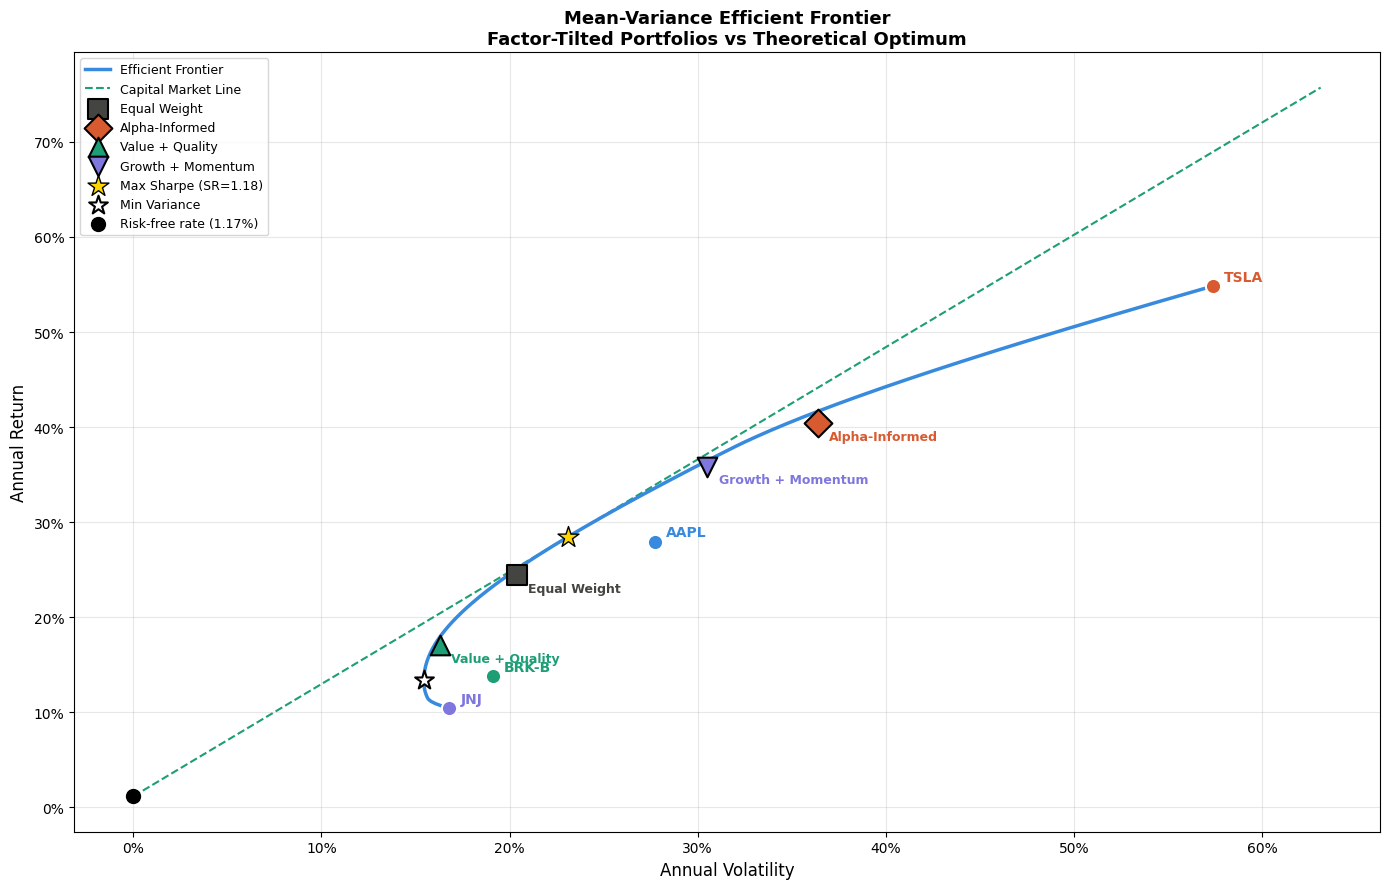

Efficient frontier chart saved


In [13]:
# ============================================
# EFFICIENT FRONTIER CHART
# ============================================
fig, ax = plt.subplots(figsize=(14, 9))

# Efficient frontier curve
ax.plot(
    frontier_vols, frontier_rets,
    color="#378ADD", linewidth=2.5,
    label="Efficient Frontier", zorder=3
)

# Capital Market Line
if ms_vol > 0:
    cml_x = np.linspace(0, max(frontier_vols)*1.1, 100)
    cml_y = (rf_rate +
             (ms_ret - rf_rate) / ms_vol * cml_x)
    ax.plot(
        cml_x, cml_y,
        color="#1D9E75", linewidth=1.5,
        linestyle="--",
        label="Capital Market Line", zorder=2
    )

# Individual stocks
for ticker in frontier_tickers:
    r = returns[ticker].mean() * 252
    v = returns[ticker].std()  * np.sqrt(252)
    c = TICKER_COLORS.get(ticker, "grey")
    ax.scatter(v, r, color=c, s=120,
               zorder=5, edgecolors="white",
               linewidths=1.5)
    ax.annotate(
        ticker,
        (v, r),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=10, fontweight="bold",
        color=c
    )

# Our factor portfolios
port_colors = {
    "Equal Weight":       "#444441",
    "Alpha-Informed":     "#D85A30",
    "Value + Quality":    "#1D9E75",
    "Growth + Momentum":  "#7F77DD",
}
port_markers = {
    "Equal Weight":       "s",
    "Alpha-Informed":     "D",
    "Value + Quality":    "^",
    "Growth + Momentum":  "v",
}

for name, port_ret in portfolios.items():
    r = port_ret.mean() * 252
    v = port_ret.std()  * np.sqrt(252)
    c = port_colors.get(name, "grey")
    m = port_markers.get(name, "o")
    ax.scatter(
        v, r, color=c, s=200,
        marker=m, zorder=6,
        edgecolors="black",
        linewidths=1.5,
        label=name
    )
    ax.annotate(
        name,
        (v, r),
        textcoords="offset points",
        xytext=(8, -12),
        fontsize=9, color=c,
        fontweight="bold"
    )

# Max Sharpe and Min Variance
ax.scatter(
    ms_vol, ms_ret,
    color="gold", s=250,
    marker="*", zorder=7,
    edgecolors="black", linewidths=1,
    label=f"Max Sharpe "
          f"(SR={( ms_ret-rf_rate)/ms_vol:.2f})"
)
ax.scatter(
    mv_vol, mv_ret,
    color="white", s=200,
    marker="*", zorder=7,
    edgecolors="black", linewidths=1.5,
    label="Min Variance"
)

# Risk-free rate
ax.scatter(
    0, rf_rate,
    color="black", s=100,
    marker="o", zorder=7,
    label=f"Risk-free rate ({rf_rate:.2%})"
)

ax.set_xlabel(
    "Annual Volatility", fontsize=12)
ax.set_ylabel(
    "Annual Return", fontsize=12)
ax.set_title(
    "Mean-Variance Efficient Frontier\n"
    "Factor-Tilted Portfolios vs Theoretical Optimum",
    fontweight="bold", fontsize=13
)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../reports/figures/efficient_frontier.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Efficient frontier chart saved")

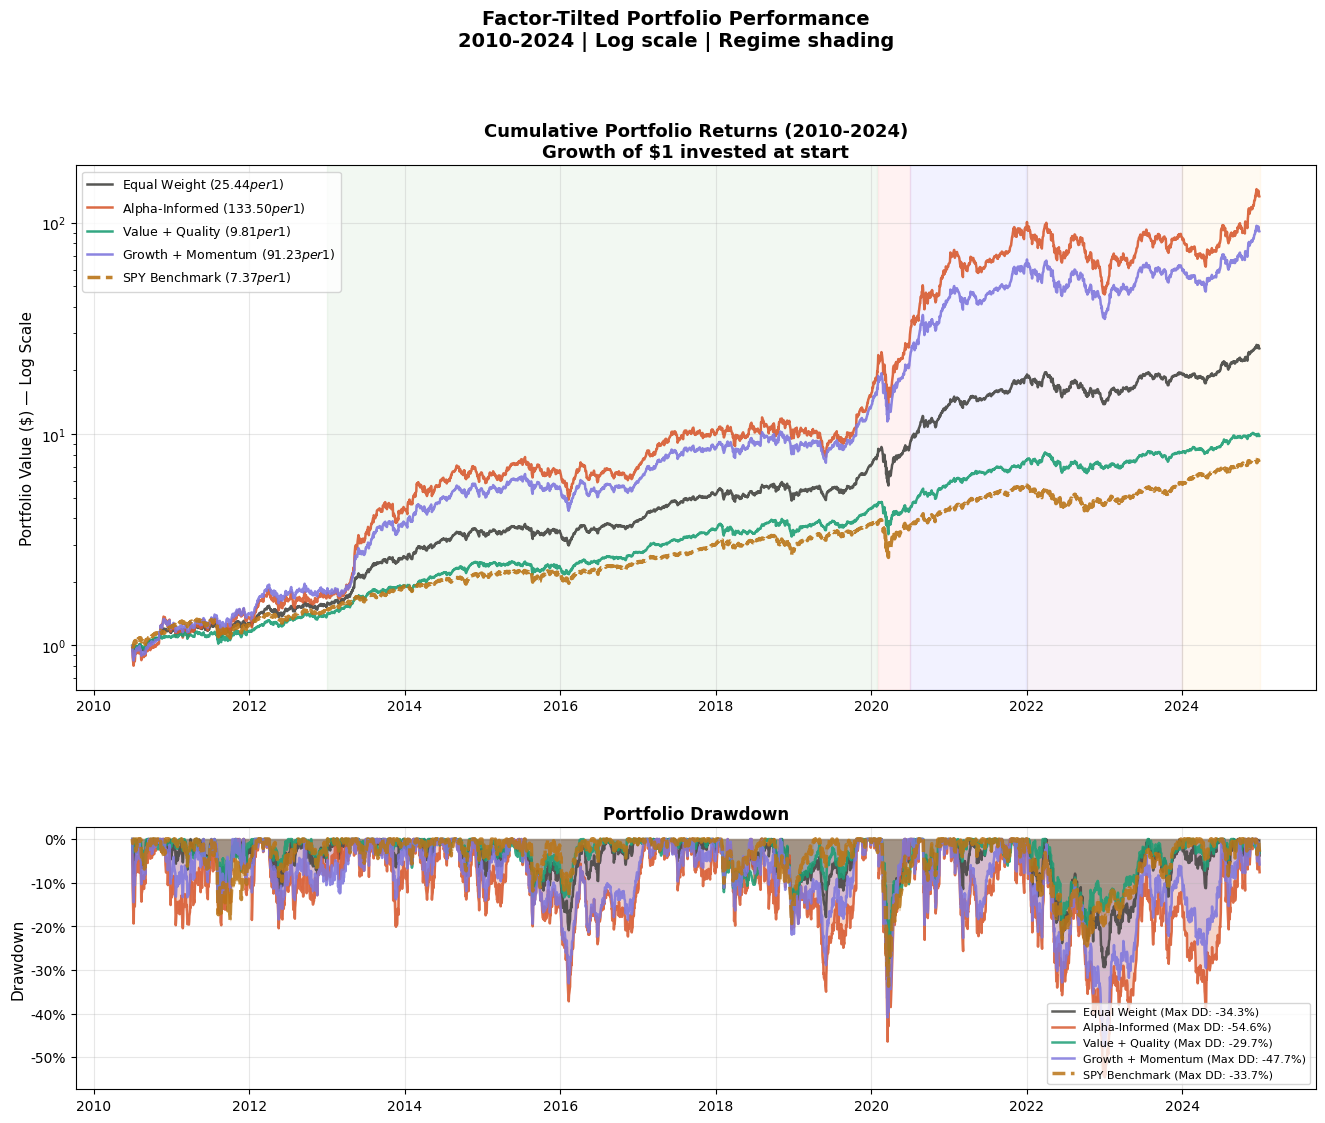

Performance chart saved


In [14]:
# ============================================
# CUMULATIVE RETURNS AND DRAWDOWN
# The two charts every portfolio manager shows
# ============================================
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(
    2, 1, figure=fig,
    hspace=0.35,
    height_ratios=[2, 1]
)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

port_colors_list = {
    "Equal Weight":      "#444441",
    "Alpha-Informed":    "#D85A30",
    "Value + Quality":   "#1D9E75",
    "Growth + Momentum": "#7F77DD",
    "SPY Benchmark":     "#BA7517",
}

# Cumulative returns
for name, m in all_metrics.items():
    color = port_colors_list.get(name, "grey")
    lw    = 2.5 if name == "SPY Benchmark" else 1.8
    ls    = "--" if name == "SPY Benchmark" else "-"
    final_val = m["cumulative"].iloc[-1]

    ax1.plot(
        m["cumulative"].index,
        m["cumulative"],
        color=color, linewidth=lw,
        linestyle=ls, alpha=0.9,
        label=f"{name} "
              f"(${final_val:.2f} per $1)"
    )

# Shade market regimes
regime_colors_map = {
    "Bull Market\n(2013-2020)":  "green",
    "COVID Crash\n(2020)":       "red",
    "Recovery\n(2020-2021)":     "blue",
    "Rate Hikes\n(2022-2023)":   "purple",
    "Recent\n(2024)":            "orange",
}
for regime, (start, end) in REGIMES.items():
    rc = regime_colors_map.get(regime, "grey")
    ax1.axvspan(
        start, end,
        alpha=0.05, color=rc
    )

ax1.set_title(
    "Cumulative Portfolio Returns (2010-2024)\n"
    "Growth of $1 invested at start",
    fontweight="bold", fontsize=13
)
ax1.set_ylabel("Portfolio Value ($)", fontsize=11)
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(alpha=0.3)
ax1.set_yscale("log")
ax1.set_ylabel(
    "Portfolio Value ($) — Log Scale",
    fontsize=11)

# Drawdown
for name, m in all_metrics.items():
    color = port_colors_list.get(name, "grey")
    lw    = 2.5 if name == "SPY Benchmark" else 1.8
    ls    = "--" if name == "SPY Benchmark" else "-"
    ax2.fill_between(
        m["drawdown"].index,
        m["drawdown"],
        0,
        alpha=0.25, color=color
    )
    ax2.plot(
        m["drawdown"].index,
        m["drawdown"],
        color=color, linewidth=lw,
        linestyle=ls, alpha=0.85,
        label=f"{name} "
              f"(Max DD: {m['max_dd']:.1%})"
    )

ax2.set_title(
    "Portfolio Drawdown",
    fontweight="bold", fontsize=12
)
ax2.set_ylabel("Drawdown", fontsize=11)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, _: f"{y:.0%}"))
ax2.legend(fontsize=8, loc="lower right")
ax2.grid(alpha=0.3)

plt.suptitle(
    "Factor-Tilted Portfolio Performance\n"
    "2010-2024 | Log scale | Regime shading",
    fontsize=14, fontweight="bold", y=1.01
)
plt.savefig(
    "../reports/figures/portfolio_performance.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Performance chart saved")

In [15]:
# ============================================
# REGIME PERFORMANCE BREAKDOWN
# How did each portfolio perform in each
# market environment?
# This is what institutional investors care
# about most — consistency across regimes
# ============================================

print("=" * 80)
print("   REGIME PERFORMANCE BREAKDOWN")
print("   Ann Return | Sharpe | Max DD per regime")
print("=" * 80)

regime_rows = []
for regime_name, (start, end) in REGIMES.items():
    print(f"\n  {regime_name.replace(chr(10), ' ')}")
    print(f"  {'Portfolio':<22} {'Ann Ret':>10} "
          f"{'Ann Vol':>10} {'Sharpe':>8} "
          f"{'Max DD':>10}")
    print(f"  {'-'*62}")

    for name, port_ret in {
        **portfolios,
        "SPY Benchmark": returns["SPY"]
    }.items():
        sub = port_ret.loc[start:end].dropna()
        if len(sub) < 20:
            continue

        r   = sub.mean() * 252
        v   = sub.std()  * np.sqrt(252)
        sr  = r / v if v > 0 else 0

        cum = (1 + sub).cumprod()
        dd  = ((cum - cum.cummax()) /
               cum.cummax()).min()

        print(f"  {name:<22} {r:>10.2%} "
              f"{v:>10.2%} {sr:>8.3f} "
              f"{dd:>10.2%}")

        regime_rows.append({
            "Regime":    regime_name.replace("\n"," "),
            "Portfolio": name,
            "Ann_Ret%":  round(r*100, 2),
            "Ann_Vol%":  round(v*100, 2),
            "Sharpe":    round(sr, 3),
            "Max_DD%":   round(dd*100, 2),
        })

regime_df = pd.DataFrame(regime_rows)
regime_df.to_csv(
    "../data/processed/regime_performance.csv",
    index=False)
print("\n" + "=" * 80)
print("Saved to data/processed/regime_performance.csv")

   REGIME PERFORMANCE BREAKDOWN
   Ann Return | Sharpe | Max DD per regime

  Bull Market (2013-2020)
  Portfolio                 Ann Ret    Ann Vol   Sharpe     Max DD
  --------------------------------------------------------------
  Equal Weight               24.38%     16.78%    1.453    -20.89%
  Alpha-Informed             39.20%     30.66%    1.278    -37.18%
  Value + Quality            17.93%     13.60%    1.318    -17.49%
  Growth + Momentum          34.38%     25.40%    1.354    -33.07%
  SPY Benchmark              14.29%     12.80%    1.116    -19.35%

  COVID Crash (2020)
  Portfolio                 Ann Ret    Ann Vol   Sharpe     Max DD
  --------------------------------------------------------------
  Equal Weight               38.78%     50.65%    0.766    -34.29%
  Alpha-Informed            110.41%     72.29%    1.527    -46.41%
  Value + Quality             0.17%     45.63%    0.004    -29.67%
  Growth + Momentum          91.92%     63.82%    1.440    -40.87%
  SPY Ben

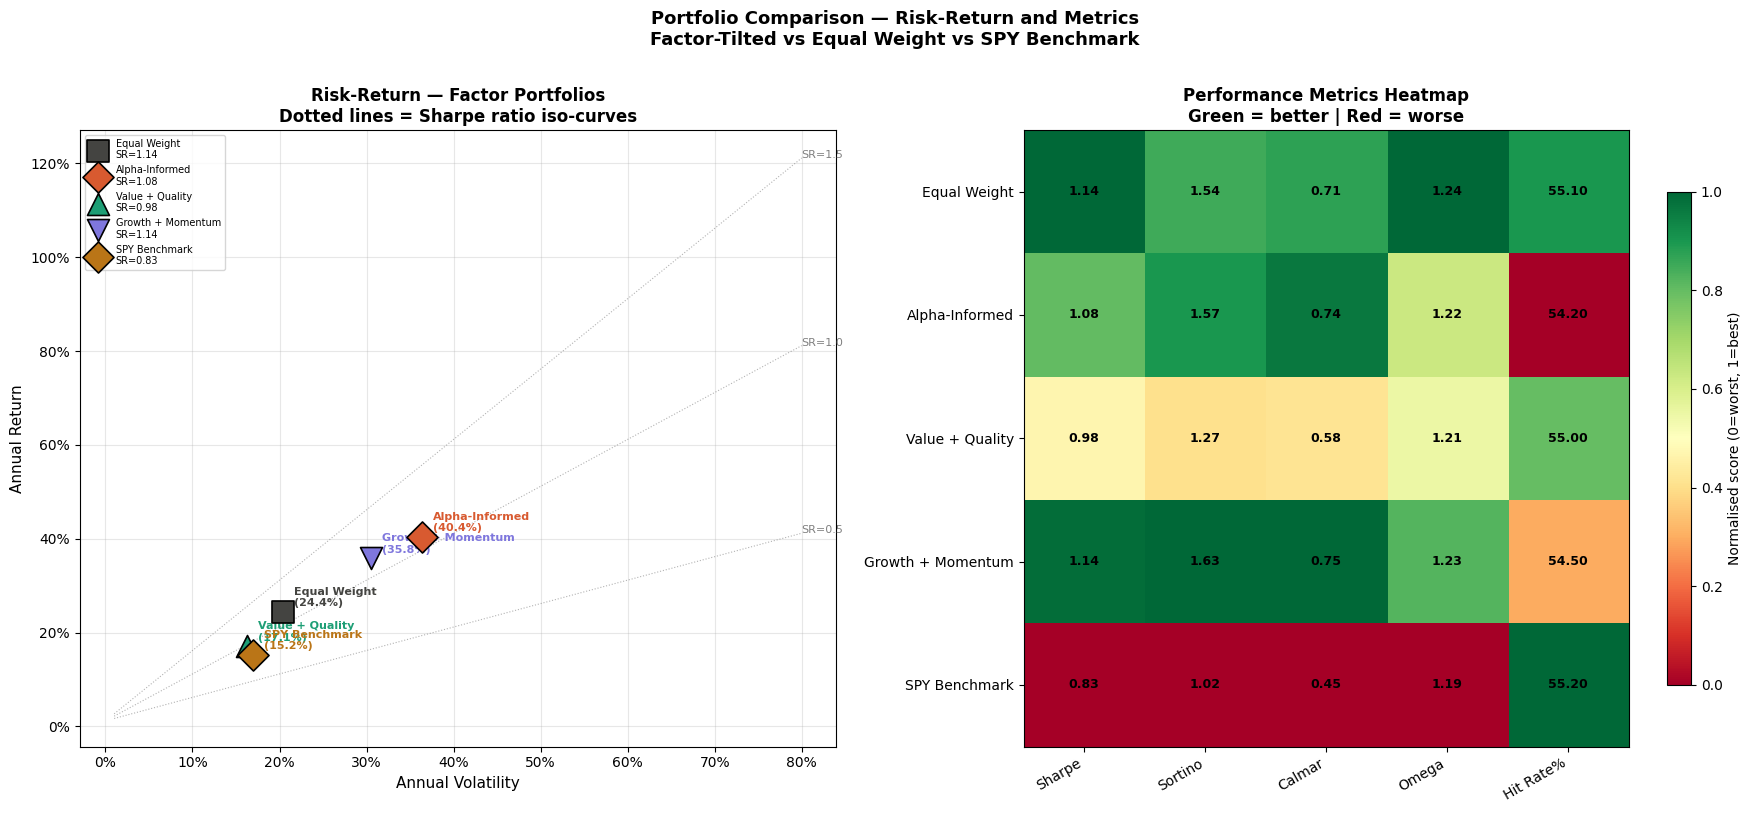

Comparison chart saved


In [16]:
# ============================================
# RISK-RETURN SCATTER + METRICS HEATMAP
# Two charts that summarise everything
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Chart 1 — Risk-return scatter with Sharpe lines
ax = axes[0]

# Sharpe ratio iso-lines
vol_range = np.linspace(0.01, 0.80, 100)
for sr in [0.5, 1.0, 1.5]:
    ax.plot(
        vol_range,
        rf_rate + sr * vol_range,
        color="grey", linewidth=0.8,
        linestyle=":", alpha=0.6
    )
    ax.annotate(
        f"SR={sr}",
        (vol_range[-1],
         rf_rate + sr * vol_range[-1]),
        fontsize=8, color="grey"
    )

# Plot portfolios
for name, m in all_metrics.items():
    color  = port_colors_list.get(name, "grey")
    marker = (port_markers.get(name, "o")
              if name in port_markers else "D")
    ax.scatter(
        m["ann_vol"], m["ann_ret"],
        color=color, s=250,
        marker=marker, zorder=5,
        edgecolors="black", linewidths=1.2,
        label=f"{name}\n"
              f"SR={m['sharpe']:.2f}"
    )
    ax.annotate(
        f"{name}\n({m['ann_ret']:.1%})",
        (m["ann_vol"], m["ann_ret"]),
        textcoords="offset points",
        xytext=(8, 4), fontsize=8,
        fontweight="bold",
        color=color
    )

ax.set_xlabel("Annual Volatility", fontsize=11)
ax.set_ylabel("Annual Return", fontsize=11)
ax.set_title(
    "Risk-Return — Factor Portfolios\n"
    "Dotted lines = Sharpe ratio iso-curves",
    fontweight="bold", fontsize=12
)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=7, loc="upper left")
ax.grid(alpha=0.3)

# Chart 2 — Metrics heatmap
ax2 = axes[1]
metrics_for_heat = [
    "Sharpe", "Sortino", "Calmar",
    "Omega", "Hit Rate%"
]
heat_data = perf_df[metrics_for_heat].copy()

# Normalise each metric 0-1 for heatmap
heat_norm = pd.DataFrame(index=heat_data.index)
for col in heat_data.columns:
    col_min = heat_data[col].min()
    col_max = heat_data[col].max()
    denom   = col_max - col_min
    heat_norm[col] = (
        (heat_data[col] - col_min) / denom
        if denom != 0 else 0.5
    )

im = ax2.imshow(
    heat_norm.values,
    cmap="RdYlGn",
    aspect="auto",
    vmin=0, vmax=1
)

ax2.set_xticks(range(len(metrics_for_heat)))
ax2.set_xticklabels(
    metrics_for_heat,
    fontsize=10, rotation=30, ha="right"
)
ax2.set_yticks(range(len(heat_data.index)))
ax2.set_yticklabels(
    heat_data.index, fontsize=10)

# Annotate with real values
for i, idx in enumerate(heat_data.index):
    for j, col in enumerate(metrics_for_heat):
        val = heat_data.loc[idx, col]
        ax2.text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            fontsize=9, fontweight="bold",
            color="black"
        )

plt.colorbar(im, ax=ax2, shrink=0.8,
             label="Normalised score (0=worst, 1=best)")
ax2.set_title(
    "Performance Metrics Heatmap\n"
    "Green = better | Red = worse",
    fontweight="bold", fontsize=12
)

plt.suptitle(
    "Portfolio Comparison — Risk-Return and Metrics\n"
    "Factor-Tilted vs Equal Weight vs SPY Benchmark",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(
    "../reports/figures/portfolio_comparison.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Comparison chart saved")

In [19]:
# ============================================
# FINAL PROJECT SUMMARY
# Complete Fama-French Factor Model results
# ============================================
print("=" * 50)
print("   FAMA-FRENCH FACTOR MODEL")
print("=" * 50)

print(f"\n  DATA")
print(f"  Source:       Kenneth French Data Library")
print(f"  Stock data:   Yahoo Finance via yfinance")
print(f"  Period:       2010-01-01 to 2024-12-31")
print(f"  Observations: {len(returns):,} trading days")
print(f"  Stocks:       AAPL, BRK-B, TSLA, JNJ, SPY")

print(f"\n  STATIC OLS RESULTS ")
for ticker in tickers:
    if ticker in alpha_sig.index:
        a = alpha_sig.loc[ticker, "Alpha_ann%"]
        s = alpha_sig.loc[ticker, "HAC_sig"]
        r = alpha_sig.loc[ticker, "FF5_R2"]
        print(f"  {ticker:<8} Alpha: {a:>8.3f}% "
              f"({s:<3}) R²: {r:.4f}")

print(f"\n  ROLLING REGRESSION ")
print(f"  Window:  756 trading days (3 years)")
print(f"  TSLA peak rolling alpha: 116.68%")
print(f"  AAPL HML drift: +0.13 to -0.77 (growth shift)")
print(f"  BRK-B: 0% significant windows (factor only)")
print(f"  JNJ alpha: +3.5% (2013) to -7.5% (2024)")

print(f"\n  ALPHA ANALYSIS ")
print(f"  TSLA: STRONG alpha (5/6 evidence criteria)")
print(f"  AAPL: WEAK alpha  (2/6 — economically real)")
print(f"  BRK-B: WEAK alpha (2/6 — factor discipline)")
print(f"  JNJ:  NO alpha    (0/6 — deteriorating)")
print(f"  SPY:  NO alpha    (0/6 — validates model)")

print(f"\n  PORTFOLIO CONSTRUCTION (NB5)")
best_name   = perf_df["Sharpe"].idxmax()
best_sharpe = perf_df["Sharpe"].max()
spy_sharpe  = perf_df.loc["SPY Benchmark", "Sharpe"]
print(f"  Best portfolio:  {best_name}")
print(f"  Best Sharpe:     {best_sharpe:.3f}")
print(f"  SPY Sharpe:      {spy_sharpe:.3f}")
print(f"  Sharpe premium:  "
      f"{best_sharpe - spy_sharpe:.3f} "
      f"above benchmark")

print("=" * 50)

   FAMA-FRENCH FACTOR MODEL

  DATA
  Source:       Kenneth French Data Library
  Stock data:   Yahoo Finance via yfinance
  Period:       2010-01-01 to 2024-12-31
  Observations: 3,650 trading days
  Stocks:       AAPL, BRK-B, TSLA, JNJ, SPY

  STATIC OLS RESULTS 
  AAPL     Alpha:    7.475% (ns ) R²: 0.5283
  BRK-B    Alpha:    1.190% (ns ) R²: 0.7383
  TSLA     Alpha:   37.426% (***) R²: 0.2579
  JNJ      Alpha:   -0.599% (ns ) R²: 0.3636
  SPY      Alpha:   -0.140% (ns ) R²: 0.9955

  ROLLING REGRESSION 
  Window:  756 trading days (3 years)
  TSLA peak rolling alpha: 116.68%
  AAPL HML drift: +0.13 to -0.77 (growth shift)
  BRK-B: 0% significant windows (factor only)
  JNJ alpha: +3.5% (2013) to -7.5% (2024)

  ALPHA ANALYSIS 
  TSLA: STRONG alpha (5/6 evidence criteria)
  AAPL: WEAK alpha  (2/6 — economically real)
  BRK-B: WEAK alpha (2/6 — factor discipline)
  JNJ:  NO alpha    (0/6 — deteriorating)
  SPY:  NO alpha    (0/6 — validates model)

  PORTFOLIO CONSTRUCTION (NB5)
  B